|<h2>Course:</h2>|<h1><a href="https://udemy.com/course/dullms_x/?couponCode=202508" target="_blank">A deep understanding of AI language model mechanisms</a></h1>|
|-|:-:|
|<h2>Part 1:</h2>|<h1>Tokenizations and embeddings<h1>|
|<h2>Section:</h2>|<h1>Embedding spaces<h1>|
|<h2>Lecture:</h2>|<h1><b>CodeChallenge HELPER: Wikipedia vs. Twitter embeddings<b></h1>|

<br>

<h5><b>Teacher:</b> Mike X Cohen, <a href="https://sincxpress.com" target="_blank">sincxpress.com</a></h5>
<h5><b>Course URL:</b> <a href="https://udemy.com/course/dullms_x/?couponCode=202508" target="_blank">udemy.com/course/dullms_x/?couponCode=202508</a></h5>
<i>Using the code without the course may lead to confusion or errors.</i>

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

# svg figure format
import matplotlib_inline.backend_inline
matplotlib_inline.backend_inline.set_matplotlib_formats('svg')

# Exercise 1: Download and inspect the models

In [1]:
# NOTE: If you get errors importing, run the following !pip... line,
# then restart your session (from Runtime menu) and comment out the pip line.
!pip install gensim

import gensim.downloader as api

# download the wikipedia and twitter models
wiki = api.load('glove-wiki-gigaword-50')
twit = api.load('glove-twitter-50')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 63.9 MB/s eta 0:00:00:00:0100:01
[==================================================] 100.0% 66.0/66.0MB downloaded
[==================================================] 100.0% 199.5/199.5MB downloaded


In [ ]:
dir(twit)

In [3]:
wiki.vector_size

50

In [5]:
# embedding matrix dimensions
print(f'Wikipedia model has {wiki.vectors.shape[0]} words and {wiki.vectors.shape[1]} embedding dimensions.')
print(f'Twitter model has {twit.vectors.shape[0]} words and {twit.vectors.shape[1]} embedding dimensions.')

Wikipedia model has 400000 words and 50 embedding dimensions.
Twitter model has 1193514 words and 50 embedding dimensions.


# Exercise 2: Visualize the embeddings for one word

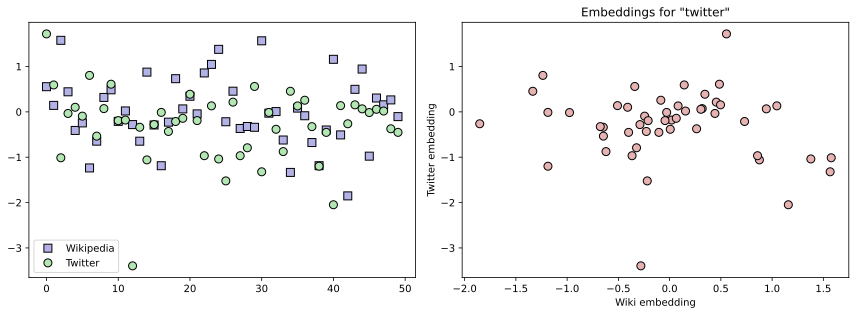

In [11]:
targetword = 'twitter'

_,axs = plt.subplots(1,2,figsize=(12,4.5))
axs[0].plot(wiki[targetword],'ks',markerfacecolor=[.7,.7,.9],markersize=8,label='Wikipedia')
axs[0].plot(twit[targetword],'ko',markerfacecolor=[.7,.9,.7],markersize=8,label='Twitter')
# axs[0].set(
axs[0].legend()

axs[1].plot(wiki[targetword],twit[targetword],'ko',markerfacecolor=[.9,.7,.7],markersize=8)
axs[1].set(xlabel='Wiki embedding',ylabel='Twitter embedding',title=f'Embeddings for "{targetword}"')

plt.tight_layout()
plt.show()

# Exercise 3: Embeddings for word pairs within each model

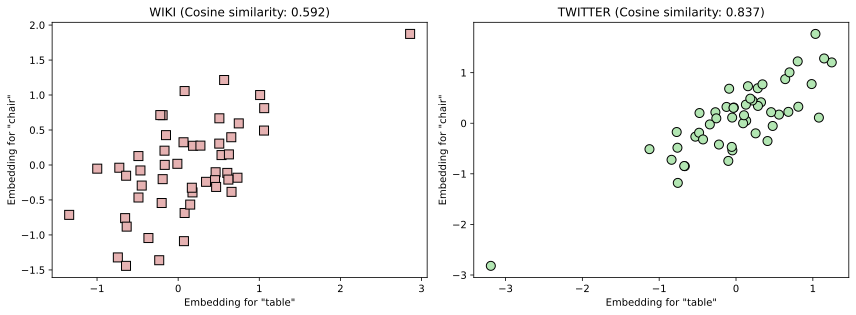

In [14]:
# word pair
word1 = 'table'
word2 = 'chair'

# scatter plot for wiki
_,axs = plt.subplots(1,2,figsize=(12,4.5))
axs[0].plot(wiki[word1],wiki[word2],'ks',markersize=9,markerfacecolor=[.9,.7,.7])
axs[0].set(xlabel=f'Embedding for "{word1}"',ylabel=f'Embedding for "{word2}"',
           title=f'WIKI (Cosine similarity: {wiki.similarity(word1,word2):.3f})')


# scatter plot for twitter
axs[1].plot(twit[word1],twit[word2],'ko',markersize=9,markerfacecolor=[.7,.9,.7])
axs[1].set(xlabel=f'Embedding for "{word1}"',ylabel=f'Embedding for "{word2}"',
           title=f'TWITTER (Cosine similarity: {twit.similarity(word1,word2):.3f})')

plt.tight_layout()
plt.show()

# Exercise 4: Similar words within each model

In [19]:
target='wikipedia'
print('10 words most similar to "battery" in wiki:')
for word, similarity in wiki.most_similar(target,topn=10):
    print(f'  {word:>15}  {similarity:.3f}')
print('\nAnd in twitter:')
for word, similarity in twit.most_similar(target,topn=10):
    print(f'  {word:>15}  {similarity:.3f}')

10 words most similar to "battery" in wiki:
  german-language  0.741
  english-language  0.723
     dictionaries  0.720
       dictionary  0.716
          publish  0.716
          website  0.704
     encyclopedia  0.701
             blog  0.699
       periodical  0.696
         editions  0.691

And in twitter:
           google  0.788
         facebook  0.748
              web  0.745
             user  0.724
         linkedin  0.723
              app  0.720
             blog  0.714
              url  0.711
            gmail  0.708
          youtube  0.706


# Exercise 5: foxes and dogs

In [23]:
text = 'The quick brown fox jumps over the lazy dog'

import re
words = re.split('\\s',text.lower())

# index sequence in the two embeddings
wiki_idx = [wiki.key_to_index[w] if w in wiki.key_to_index else np.Inf for w in words ]
twit_idx = [twit.key_to_index[w] if w in twit.key_to_index else np.Inf for w in words ]

print(' Word |  Wiki | Twitter')
print('-'*23)
for o,w,t in zip(words,wiki_idx,twit_idx):
  print(f'{o:>5} | {w:>5} | {t:>5}')

 Word |  Wiki | Twitter
-----------------------
  the |     0 |    13
quick |  2582 |  2156
brown |  1042 |  1871
  fox |  2106 |  4000
jumps | 11070 | 18014
 over |    74 |   254
  the |     0 |    13
 lazy | 16531 |  2222
  dog |  2926 |  1317


Word pair: the-over  Wiki: 0.824  Twitter: 0.795  Distance to unity line: 0.021
Word pair: quick-jumps  Wiki: 0.479  Twitter: 0.456  Distance to unity line: 0.016
Word pair: quick-over  Wiki: 0.613  Twitter: 0.653  Distance to unity line: 0.028
Word pair: brown-fox  Wiki: 0.605  Twitter: 0.652  Distance to unity line: 0.033
Word pair: brown-over  Wiki: 0.569  Twitter: 0.581  Distance to unity line: 0.008
Word pair: jumps-dog  Wiki: 0.380  Twitter: 0.441  Distance to unity line: 0.043
Word pair: over-the  Wiki: 0.824  Twitter: 0.795  Distance to unity line: 0.021
Word pair: lazy-dog  Wiki: 0.613  Twitter: 0.673  Distance to unity line: 0.042


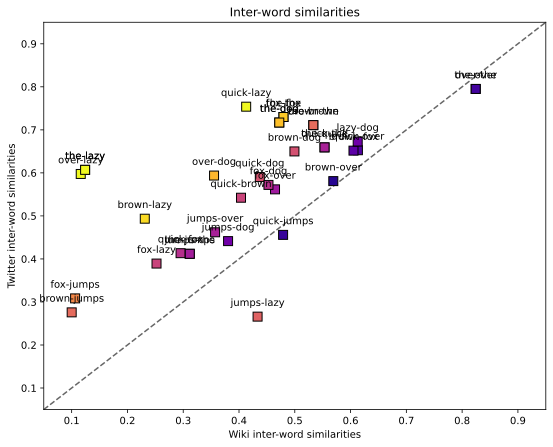

In [30]:
# get all unique inter-word similarities

plt.figure(figsize=(9,7))

# start range at 0 or 1?
for i in range(0,len(words)):
  for j in range(i+1,len(words)):

    # skip identity
    if words[i]==words[j]: continue

    # calculate the cosine similarities for the two embeddings
    cs_wiki = wiki.similarity(wiki_idx[i],wiki_idx[j])
    cs_twit = twit.similarity(twit_idx[i],twit_idx[j])

    # calculate the distance to the unity line
    v = np.array([cs_wiki,cs_twit])
    u = np.array([1,1])
    dist = np.linalg.norm(v - (sum(v*u))/(np.linalg.norm(u)**2)*u)

    # draw the results at the coordinates
    plt.plot(cs_wiki,cs_twit,'ks',markersize=9,markerfacecolor=mpl.cm.plasma(dist*5))

    # and write the word pair
    plt.text(cs_wiki,cs_twit+.02,f'{words[i]}-{words[j]}',va='bottom',ha='center')

    if dist<.05:
      print(f'Word pair: {words[i]}-{words[j]}  Wiki: {cs_wiki:.3f}  Twitter: {cs_twit:.3f}  Distance to unity line: {dist:.3f}')

# plot the unity line
xylims = [.05,.95]
plt.plot(xylims,xylims,'--',color=[.4,.4,.4],zorder=-30)

# final adjustments
plt.gca().set(xlim=xylims,ylim=xylims,xlabel='Wiki inter-word similarities',
              ylabel='Twitter inter-word similarities',title='Inter-word similarities')
plt.show()